In [1]:
"""
Week 1: Introduction to Machine Vision - Complete Demo
Demonstrates foundational concepts: images as matrices, pixels,
color spaces, image formats, and a basic Machine Vision pipeline.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

In [2]:
# ============================================================
# 配置常量
# Configuration Constants
# ============================================================
try:
    SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    SCRIPT_DIR = os.path.abspath("courses/mv/notes")
OUTPUT_DIR = os.path.join(SCRIPT_DIR, "week1_intro_complete_demo_pages")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 图片尺寸和DPI
# Image dimensions and DPI
FIG_WIDTH = 12
FIG_HEIGHT = 8
DPI = 150
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

Step 1: Images Are Numerical Matrices
Grayscale image shape: (6, 6)
Data type: uint8
Value range: [0, 255]

Pixel matrix:
[[  0  50 100 150 200 255]
 [ 30  80 130 180 230 255]
 [ 60 110 160 210 240 200]
 [ 90 140 190 220 180 150]
 [120 170 200 170 120 100]
 [150 200 170 120  70  50]]


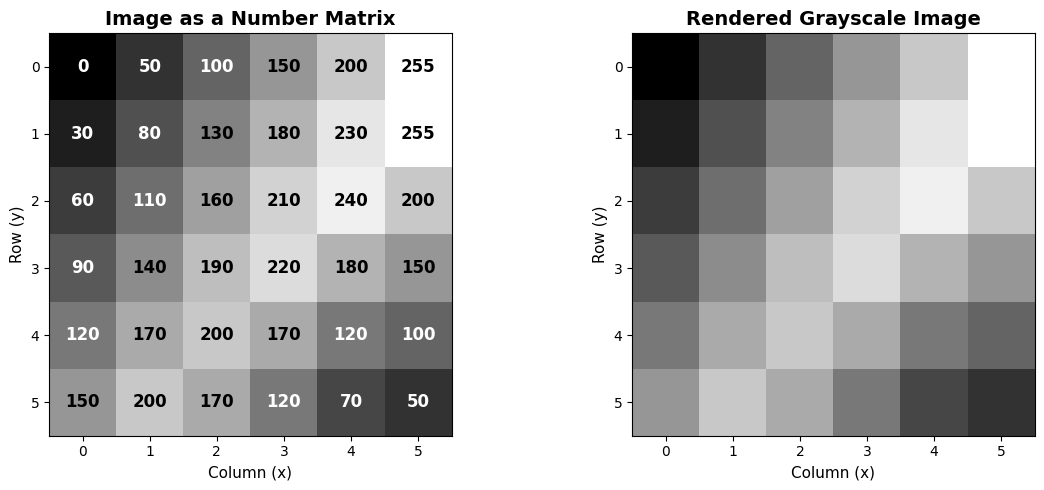


Saved: step1_image_as_matrix.png


In [3]:
# ============================================================
# 步骤 1：图像是数字矩阵
# Step 1: Images Are Numerical Matrices
# ============================================================
print("=" * 60)
print("Step 1: Images Are Numerical Matrices")
print("=" * 60)

# 创建一个小的灰度图矩阵来演示
# Create a small grayscale matrix to demonstrate
grayscale_img = np.array([
    [0,   50,  100, 150, 200, 255],
    [30,  80,  130, 180, 230, 255],
    [60,  110, 160, 210, 240, 200],
    [90,  140, 190, 220, 180, 150],
    [120, 170, 200, 170, 120, 100],
    [150, 200, 170, 120,  70,  50],
], dtype=np.uint8)

print(f"Grayscale image shape: {grayscale_img.shape}")
print(f"Data type: {grayscale_img.dtype}")
print(f"Value range: [{grayscale_img.min()}, {grayscale_img.max()}]")
print(f"\nPixel matrix:\n{grayscale_img}")

fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH, FIG_HEIGHT // 2 + 1))

# 左侧：显示数值矩阵
# Left: Show the numerical matrix
ax = axes[0]
ax.set_title("Image as a Number Matrix", fontsize=14, fontweight='bold')
for i in range(grayscale_img.shape[0]):
    for j in range(grayscale_img.shape[1]):
        val = grayscale_img[i, j]
        # 根据值选择文字颜色
        # Choose text color based on value
        text_color = 'white' if val < 128 else 'black'
        ax.text(j, i, str(val), ha='center', va='center',
                fontsize=12, color=text_color, fontweight='bold')
ax.imshow(grayscale_img, cmap='gray', vmin=0, vmax=255)
ax.set_xlabel("Column (x)", fontsize=11)
ax.set_ylabel("Row (y)", fontsize=11)

# 右侧：灰度显示
# Right: Grayscale display
ax = axes[1]
ax.set_title("Rendered Grayscale Image", fontsize=14, fontweight='bold')
ax.imshow(grayscale_img, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
ax.set_xlabel("Column (x)", fontsize=11)
ax.set_ylabel("Row (y)", fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "step1_image_as_matrix.png"), dpi=DPI, bbox_inches='tight')
plt.show()
print("\nSaved: step1_image_as_matrix.png")


Step 2: Pixels — The Basic Unit of an Image
RGB image shape: (6, 6, 3) (Height x Width x Channels)
Pixel at (0,0) = [255   0   0]  → Red
Pixel at (0,3) = [  0 255   0]  → Green
Pixel at (3,0) = [  0   0 255]  → Blue
Pixel at (3,3) = [255 255   0]  → Yellow (Red + Green)


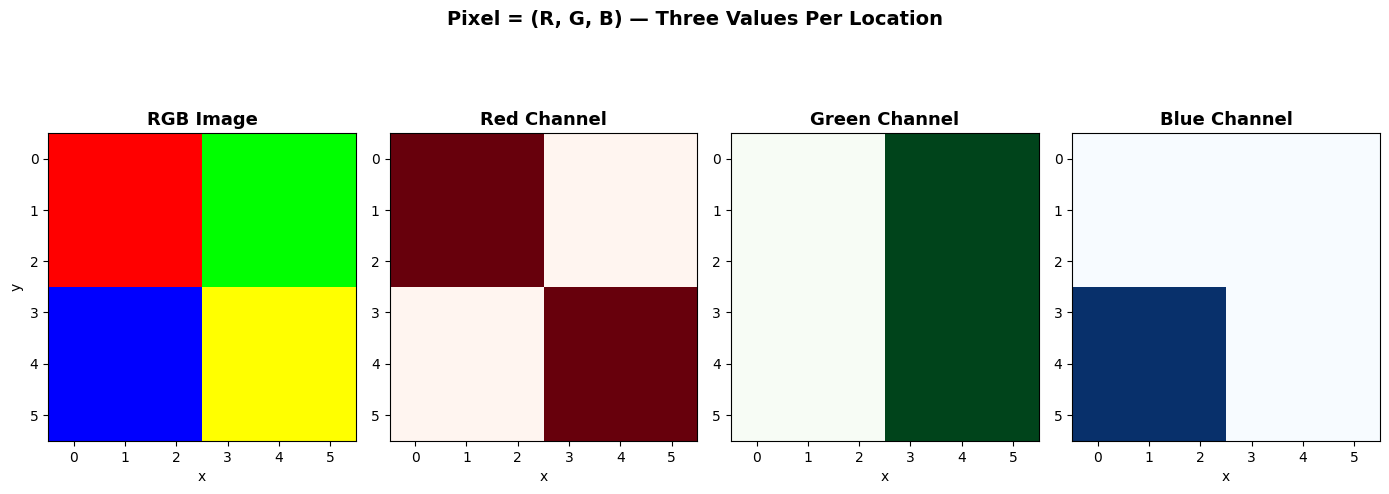


Saved: step2_pixel_rgb_channels.png


In [4]:
# ============================================================
# 步骤 2：像素（Pixel）——图像的基本单元
# Step 2: Pixels — The Basic Unit of an Image
# ============================================================
print("\n" + "=" * 60)
print("Step 2: Pixels — The Basic Unit of an Image")
print("=" * 60)

# 创建一个简单的RGB图像来演示像素
# Create a simple RGB image to demonstrate pixels
rgb_img = np.zeros((6, 6, 3), dtype=np.uint8)

# 设置不同区域的颜色
# Set different regions with colors
rgb_img[0:3, 0:3] = [255, 0, 0]     # 左上：红色 / Top-left: Red
rgb_img[0:3, 3:6] = [0, 255, 0]     # 右上：绿色 / Top-right: Green
rgb_img[3:6, 0:3] = [0, 0, 255]     # 左下：蓝色 / Bottom-left: Blue
rgb_img[3:6, 3:6] = [255, 255, 0]   # 右下：黄色 / Bottom-right: Yellow

print(f"RGB image shape: {rgb_img.shape} (Height x Width x Channels)")
print(f"Pixel at (0,0) = {rgb_img[0, 0]}  → Red")
print(f"Pixel at (0,3) = {rgb_img[0, 3]}  → Green")
print(f"Pixel at (3,0) = {rgb_img[3, 0]}  → Blue")
print(f"Pixel at (3,3) = {rgb_img[3, 3]}  → Yellow (Red + Green)")

fig, axes = plt.subplots(1, 4, figsize=(FIG_WIDTH + 2, FIG_HEIGHT // 2 + 1))

# 显示完整RGB图
# Show full RGB image
axes[0].set_title("RGB Image", fontsize=13, fontweight='bold')
axes[0].imshow(rgb_img, interpolation='nearest')
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

# 分别显示R, G, B通道
# Show R, G, B channels separately
channel_names = ['Red Channel', 'Green Channel', 'Blue Channel']
channel_cmaps = ['Reds', 'Greens', 'Blues']
for idx, (name, cmap) in enumerate(zip(channel_names, channel_cmaps)):
    axes[idx + 1].set_title(name, fontsize=13, fontweight='bold')
    axes[idx + 1].imshow(rgb_img[:, :, idx], cmap=cmap, vmin=0, vmax=255,
                          interpolation='nearest')
    axes[idx + 1].set_xlabel("x")

plt.suptitle("Pixel = (R, G, B) — Three Values Per Location",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "step2_pixel_rgb_channels.png"), dpi=DPI, bbox_inches='tight')
plt.show()
print("\nSaved: step2_pixel_rgb_channels.png")


Step 3: Color Space Comparison (RGB vs HSV)


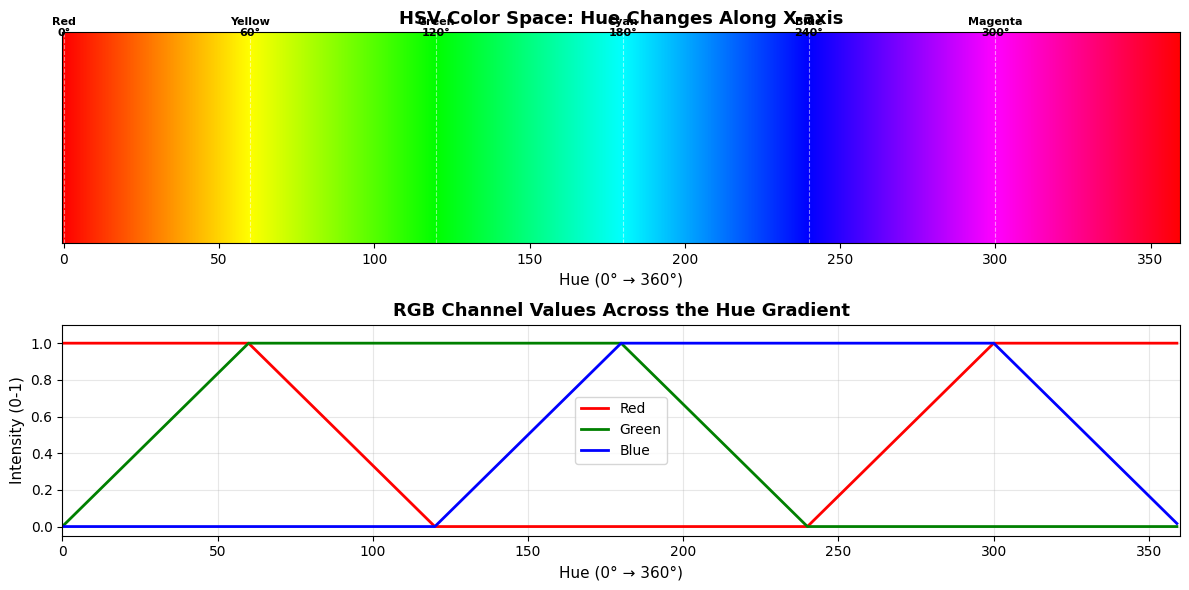

HSV separates color information:
  H (Hue)        = What color? (0-360°)
  S (Saturation)  = How vivid? (0-1)
  V (Value)       = How bright? (0-1)

RGB mixes all three dimensions:
  To find 'red' objects in RGB, you'd need complex 3D conditions
  In HSV, just filter H ≈ 0° or H ≈ 360° regardless of brightness

Saved: step3_rgb_vs_hsv.png


In [5]:
# ============================================================
# 步骤 3：色彩空间比较（RGB vs HSV）
# Step 3: Color Space Comparison (RGB vs HSV)
# ============================================================
print("\n" + "=" * 60)
print("Step 3: Color Space Comparison (RGB vs HSV)")
print("=" * 60)

# 创建一个色彩渐变图来展示RGB和HSV的区别
# Create a color gradient to show RGB vs HSV differences
height, width = 100, 360

# HSV色环：H从0到360度，S和V保持最大
# HSV color wheel: H from 0 to 360 degrees, S and V at maximum
hsv_img = np.zeros((height, width, 3), dtype=np.float32)
for x in range(width):
    h = x / width  # 色调 0-1 / Hue 0-1
    for y in range(height):
        s = 1.0  # 饱和度最大 / Full saturation
        v = 1.0  # 亮度最大 / Full value
        hsv_img[y, x] = [h, s, v]

# 将HSV转为RGB用于显示
# Convert HSV to RGB for display
from matplotlib.colors import hsv_to_rgb
rgb_from_hsv = hsv_to_rgb(hsv_img)

fig, axes = plt.subplots(2, 1, figsize=(FIG_WIDTH, FIG_HEIGHT // 2 + 2))

# HSV色环
# HSV color wheel
axes[0].imshow(rgb_from_hsv, aspect='auto')
axes[0].set_title("HSV Color Space: Hue Changes Along X-axis", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Hue (0° → 360°)", fontsize=11)
axes[0].set_yticks([])
# 标注关键颜色
# Mark key colors
color_labels = {0: 'Red', 60: 'Yellow', 120: 'Green', 180: 'Cyan', 240: 'Blue', 300: 'Magenta'}
for deg, label in color_labels.items():
    x_pos = deg
    axes[0].axvline(x=x_pos, color='white', linestyle='--', alpha=0.5, linewidth=0.8)
    axes[0].text(x_pos, -8, f"{label}\n{deg}°", ha='center', va='top', fontsize=8,
                 fontweight='bold')

# RGB 分离：展示同一渐变下R/G/B通道的变化
# RGB channels: show how R/G/B change across the same gradient
rgb_flat = rgb_from_hsv[50, :, :]  # 取中间行 / Take middle row
x_axis = np.arange(width)
axes[1].plot(x_axis, rgb_flat[:, 0], 'r-', linewidth=2, label='Red')
axes[1].plot(x_axis, rgb_flat[:, 1], 'g-', linewidth=2, label='Green')
axes[1].plot(x_axis, rgb_flat[:, 2], 'b-', linewidth=2, label='Blue')
axes[1].set_title("RGB Channel Values Across the Hue Gradient", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Hue (0° → 360°)", fontsize=11)
axes[1].set_ylabel("Intensity (0-1)", fontsize=11)
axes[1].legend(fontsize=10)
axes[1].set_xlim(0, 360)
axes[1].set_ylim(-0.05, 1.1)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "step3_rgb_vs_hsv.png"), dpi=DPI, bbox_inches='tight')
plt.show()

print("HSV separates color information:")
print("  H (Hue)        = What color? (0-360°)")
print("  S (Saturation)  = How vivid? (0-1)")
print("  V (Value)       = How bright? (0-1)")
print("\nRGB mixes all three dimensions:")
print("  To find 'red' objects in RGB, you'd need complex 3D conditions")
print("  In HSV, just filter H ≈ 0° or H ≈ 360° regardless of brightness")
print("\nSaved: step3_rgb_vs_hsv.png")


Step 4: Image Format Comparison (JPEG vs PNG vs RAW)


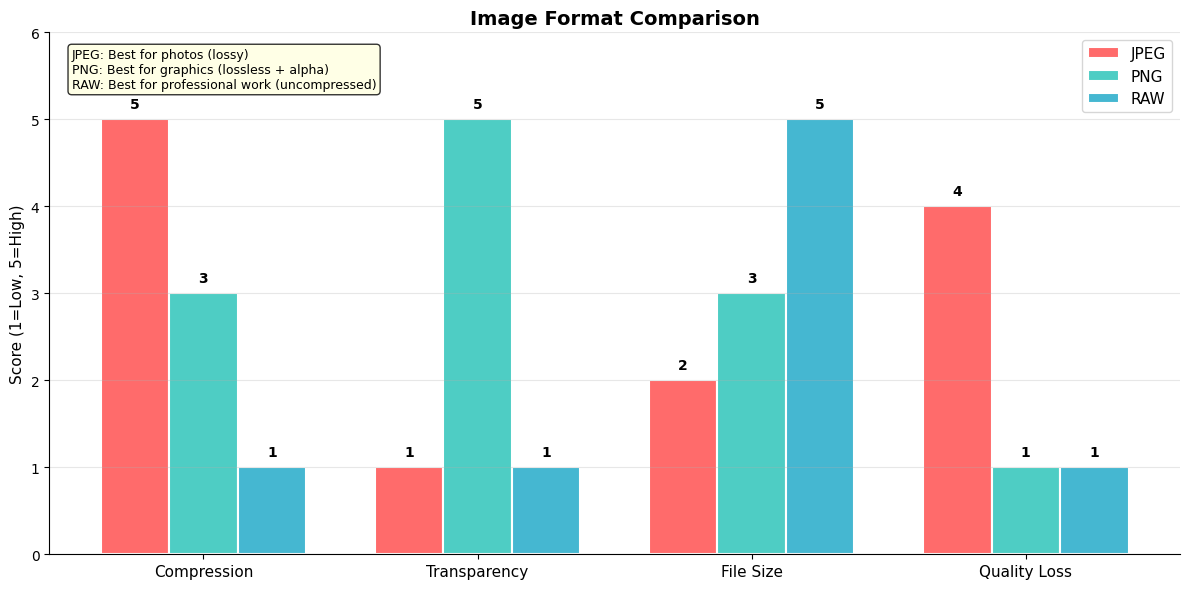

JPEG: Lossy compression, no transparency, small files
PNG:  Lossless compression, supports transparency (alpha channel)
RAW:  No compression, maximum quality, very large files

Saved: step4_image_formats.png


In [6]:
# ============================================================
# 步骤 4：图像格式比较（JPEG vs PNG vs RAW）
# Step 4: Image Format Comparison (JPEG vs PNG vs RAW)
# ============================================================
print("\n" + "=" * 60)
print("Step 4: Image Format Comparison (JPEG vs PNG vs RAW)")
print("=" * 60)

fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT // 2 + 2))

# 图像格式比较表
# Image format comparison chart
formats = ['JPEG', 'PNG', 'RAW']
categories = ['Compression', 'Transparency', 'File Size', 'Quality Loss']

# 分数构造（1-5分，5为最好/最多）
# Score construction (1-5, 5 = best/most)
#                  Compression  Transparency  File Size  Quality Loss
data = np.array([
    [5, 1, 2, 4],   # JPEG: high compression, no transparency, small file, quality loss
    [3, 5, 3, 1],   # PNG: moderate compression, transparency, medium file, no loss
    [1, 1, 5, 1],   # RAW: no compression, no transparency, huge file, no loss
])

# 使用条形图
# Use bar chart
x = np.arange(len(categories))
bar_width = 0.25
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for i, (fmt, color) in enumerate(zip(formats, colors)):
    bars = ax.bar(x + i * bar_width, data[i], bar_width, label=fmt, color=color,
                  edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, data[i]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x + bar_width)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylabel("Score (1=Low, 5=High)", fontsize=11)
ax.set_title("Image Format Comparison", fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.set_ylim(0, 6)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 添加注释
# Add annotations
ax.text(0.02, 0.97,
        "JPEG: Best for photos (lossy)\n"
        "PNG: Best for graphics (lossless + alpha)\n"
        "RAW: Best for professional work (uncompressed)",
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "step4_image_formats.png"), dpi=DPI, bbox_inches='tight')
plt.show()

print("JPEG: Lossy compression, no transparency, small files")
print("PNG:  Lossless compression, supports transparency (alpha channel)")
print("RAW:  No compression, maximum quality, very large files")
print("\nSaved: step4_image_formats.png")


Step 5: Machine Vision System Workflow


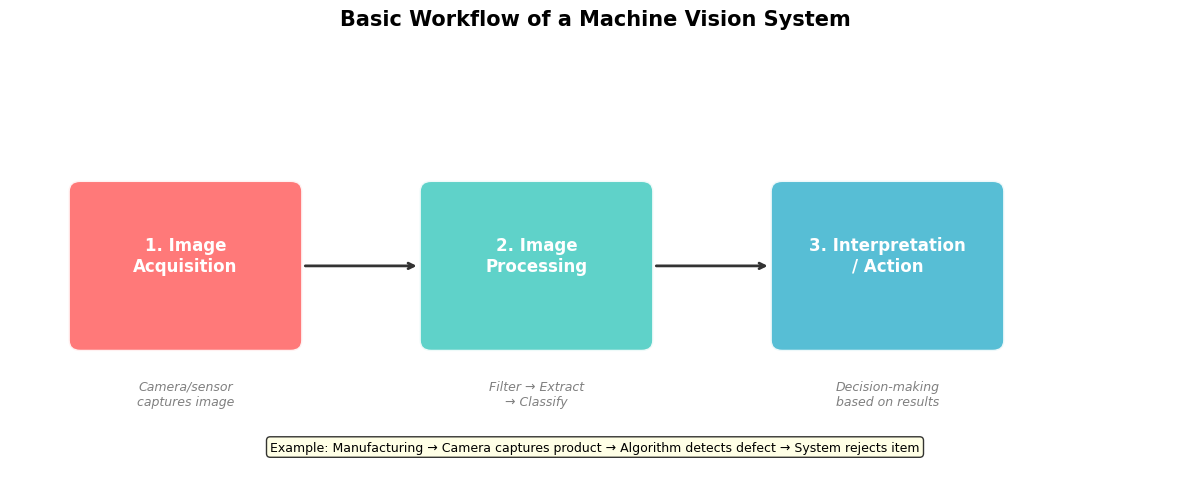

Machine Vision Workflow:
1. Image Acquisition → Camera/sensor captures image
2. Image Processing  → Analyze, filter, extract features
3. Interpretation    → Make decisions based on results

Saved: step5_mv_workflow.png


In [7]:
# ============================================================
# 步骤 5：机器视觉系统工作流
# Step 5: Machine Vision System Workflow
# ============================================================
print("\n" + "=" * 60)
print("Step 5: Machine Vision System Workflow")
print("=" * 60)

fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT // 2 + 1))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis('off')

# 三个阶段的方框
# Three stage boxes
stages = [
    (1.5, 2, "1. Image\nAcquisition", '#FF6B6B', "Camera/sensor\ncaptures image"),
    (4.5, 2, "2. Image\nProcessing", '#4ECDC4', "Filter → Extract\n→ Classify"),
    (7.5, 2, "3. Interpretation\n/ Action", '#45B7D1', "Decision-making\nbased on results"),
]

for x, y, title, color, desc in stages:
    # 主框
    # Main box
    rect = mpatches.FancyBboxPatch((x - 0.9, y - 0.7), 1.8, 1.4,
                                    boxstyle="round,pad=0.1",
                                    facecolor=color, edgecolor='white',
                                    linewidth=2, alpha=0.9)
    ax.add_patch(rect)
    ax.text(x, y + 0.1, title, ha='center', va='center',
            fontsize=12, fontweight='bold', color='white')

    # 描述文字
    # Description text
    ax.text(x, y - 1.2, desc, ha='center', va='center',
            fontsize=9, color='gray', style='italic')

# 连接箭头
# Connection arrows
arrow_style = dict(arrowstyle='->', color='#333333', linewidth=2)
ax.annotate('', xy=(3.5, 2), xytext=(2.5, 2), arrowprops=arrow_style)
ax.annotate('', xy=(6.5, 2), xytext=(5.5, 2), arrowprops=arrow_style)

ax.set_title("Basic Workflow of a Machine Vision System",
             fontsize=15, fontweight='bold', pad=20)

# 示例说明
# Example annotation
ax.text(5, 0.3,
        "Example: Manufacturing → Camera captures product → Algorithm detects defect → System rejects item",
        ha='center', va='center', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "step5_mv_workflow.png"), dpi=DPI, bbox_inches='tight')
plt.show()

print("Machine Vision Workflow:")
print("1. Image Acquisition → Camera/sensor captures image")
print("2. Image Processing  → Analyze, filter, extract features")
print("3. Interpretation    → Make decisions based on results")
print("\nSaved: step5_mv_workflow.png")


Step 6: Traditional CV vs Deep Learning CV


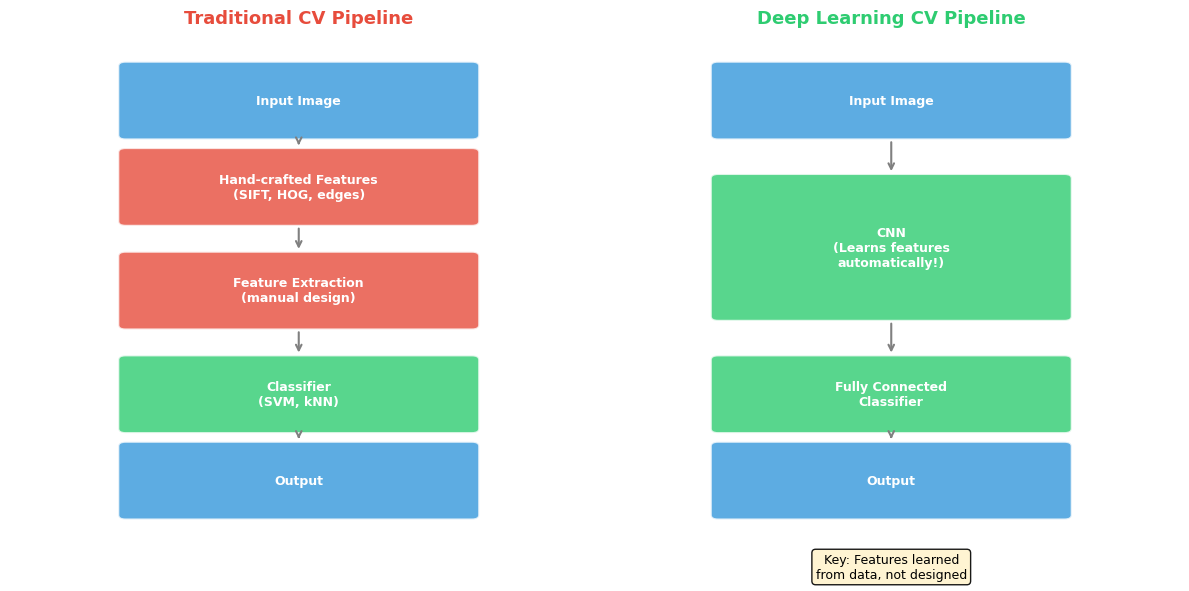

Traditional CV: Input → Hand-crafted features → Classifier → Output
Deep Learning:  Input → CNN (auto-learns features) → Output
Key difference: DL learns features FROM data; traditional requires manual design

Saved: step6_traditional_vs_dl.png


In [8]:
# ============================================================
# 步骤 6：传统CV vs 深度学习CV
# Step 6: Traditional CV vs Deep Learning CV
# ============================================================
print("\n" + "=" * 60)
print("Step 6: Traditional CV vs Deep Learning CV")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH, FIG_HEIGHT // 2 + 2))

# 传统CV流水线
# Traditional CV pipeline
ax = axes[0]
ax.set_xlim(0, 4)
ax.set_ylim(0, 6)
ax.axis('off')
ax.set_title("Traditional CV Pipeline", fontsize=13, fontweight='bold', color='#E74C3C')

trad_steps = [
    (2, 5.2, "Input Image", '#3498DB'),
    (2, 4.2, "Hand-crafted Features\n(SIFT, HOG, edges)", '#E74C3C'),
    (2, 3.0, "Feature Extraction\n(manual design)", '#E74C3C'),
    (2, 1.8, "Classifier\n(SVM, kNN)", '#2ECC71'),
    (2, 0.8, "Output", '#3498DB'),
]

for i, (x, y, text, color) in enumerate(trad_steps):
    rect = mpatches.FancyBboxPatch((x - 1.2, y - 0.4), 2.4, 0.8,
                                    boxstyle="round,pad=0.05",
                                    facecolor=color, alpha=0.8,
                                    edgecolor='white', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x, y, text, ha='center', va='center', fontsize=9,
            fontweight='bold', color='white')

    if i < len(trad_steps) - 1:
        ax.annotate('', xy=(2, trad_steps[i + 1][1] + 0.45),
                     xytext=(2, y - 0.45),
                     arrowprops=dict(arrowstyle='->', color='gray', linewidth=1.5))

# 深度学习CV流水线
# Deep Learning CV pipeline
ax = axes[1]
ax.set_xlim(0, 4)
ax.set_ylim(0, 6)
ax.axis('off')
ax.set_title("Deep Learning CV Pipeline", fontsize=13, fontweight='bold', color='#2ECC71')

dl_steps = [
    (2, 5.2, "Input Image", '#3498DB'),
    (2, 3.5, "CNN\n(Learns features\nautomatically!)", '#2ECC71'),
    (2, 1.8, "Fully Connected\nClassifier", '#2ECC71'),
    (2, 0.8, "Output", '#3498DB'),
]

for i, (x, y, text, color) in enumerate(dl_steps):
    h = 0.8 if i != 1 else 1.6  # CNN方框更大 / CNN box is larger
    rect = mpatches.FancyBboxPatch((x - 1.2, y - h / 2), 2.4, h,
                                    boxstyle="round,pad=0.05",
                                    facecolor=color, alpha=0.8,
                                    edgecolor='white', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x, y, text, ha='center', va='center', fontsize=9,
            fontweight='bold', color='white')

    if i < len(dl_steps) - 1:
        next_y = dl_steps[i + 1][1]
        next_h = 0.8 if i + 1 != 1 else 1.6
        ax.annotate('', xy=(2, next_y + next_h / 2 + 0.05),
                     xytext=(2, y - h / 2 - 0.05),
                     arrowprops=dict(arrowstyle='->', color='gray', linewidth=1.5))

# 关键区别标注
# Key difference annotation
ax.text(2, -0.2,
        "Key: Features learned\nfrom data, not designed",
        ha='center', va='center', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='#FFF3CD', alpha=0.9))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "step6_traditional_vs_dl.png"), dpi=DPI, bbox_inches='tight')
plt.show()

print("Traditional CV: Input → Hand-crafted features → Classifier → Output")
print("Deep Learning:  Input → CNN (auto-learns features) → Output")
print("Key difference: DL learns features FROM data; traditional requires manual design")
print("\nSaved: step6_traditional_vs_dl.png")


Step 7: CCD vs CMOS Sensor Comparison


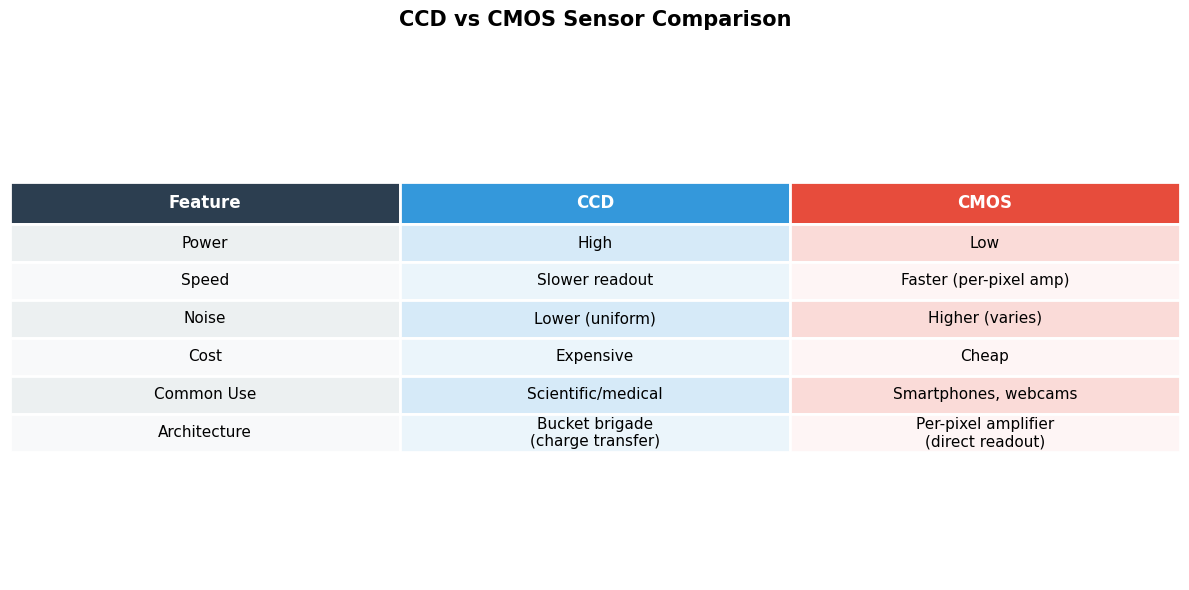

CCD: Higher quality but expensive, used in scientific/medical imaging
CMOS: Cheaper and faster, used in smartphones and webcams
Most modern cameras use CMOS sensors

Saved: step7_ccd_vs_cmos.png


In [9]:
# ============================================================
# 步骤 7：CCD vs CMOS 传感器对比
# Step 7: CCD vs CMOS Sensor Comparison
# ============================================================
print("\n" + "=" * 60)
print("Step 7: CCD vs CMOS Sensor Comparison")
print("=" * 60)

fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT // 2 + 2))
ax.axis('off')

# 比较表格数据
# Comparison table data
table_data = [
    ['Feature',         'CCD',                    'CMOS'],
    ['Power',           'High',                   'Low'],
    ['Speed',           'Slower readout',         'Faster (per-pixel amp)'],
    ['Noise',           'Lower (uniform)',        'Higher (varies)'],
    ['Cost',            'Expensive',              'Cheap'],
    ['Common Use',      'Scientific/medical',     'Smartphones, webcams'],
    ['Architecture',    'Bucket brigade\n(charge transfer)', 'Per-pixel amplifier\n(direct readout)'],
]

colors_header = ['#2C3E50', '#3498DB', '#E74C3C']
colors_row1 = ['#ECF0F1', '#D6EAF8', '#FADBD8']
colors_row2 = ['#F8F9FA', '#EBF5FB', '#FEF5F5']

table = ax.table(cellText=[row for row in table_data],
                  loc='center',
                  cellLoc='center')

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.0, 2.0)

# 格式化表头和单元格
# Format header and cells
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor(colors_header[col])
        cell.set_text_props(color='white', fontweight='bold', fontsize=12)
        cell.set_height(0.08)
    elif row % 2 == 1:
        cell.set_facecolor(colors_row1[col])
    else:
        cell.set_facecolor(colors_row2[col])
    cell.set_edgecolor('white')
    cell.set_linewidth(2)

ax.set_title("CCD vs CMOS Sensor Comparison", fontsize=15, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "step7_ccd_vs_cmos.png"), dpi=DPI, bbox_inches='tight')
plt.show()

print("CCD: Higher quality but expensive, used in scientific/medical imaging")
print("CMOS: Cheaper and faster, used in smartphones and webcams")
print("Most modern cameras use CMOS sensors")
print("\nSaved: step7_ccd_vs_cmos.png")


Step 8: Machine Vision History Timeline


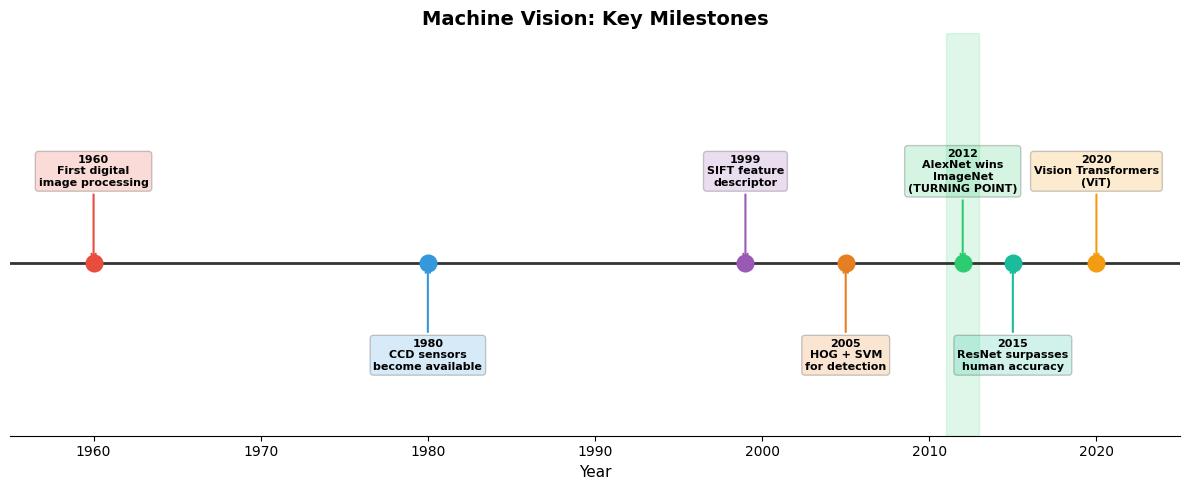

Key turning point: 2012 — AlexNet won ImageNet challenge
This marked the shift from hand-crafted features to deep learning

Saved: step8_history_timeline.png


In [10]:
# ============================================================
# 步骤 8：机器视觉历史时间线
# Step 8: Machine Vision History Timeline
# ============================================================
print("\n" + "=" * 60)
print("Step 8: Machine Vision History Timeline")
print("=" * 60)

fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT // 2 + 1))

# 时间线数据
# Timeline data
milestones = [
    (1960, "First digital\nimage processing", '#E74C3C'),
    (1980, "CCD sensors\nbecome available", '#3498DB'),
    (1999, "SIFT feature\ndescriptor", '#9B59B6'),
    (2005, "HOG + SVM\nfor detection", '#E67E22'),
    (2012, "AlexNet wins\nImageNet\n(TURNING POINT)", '#2ECC71'),
    (2015, "ResNet surpasses\nhuman accuracy", '#1ABC9C'),
    (2020, "Vision Transformers\n(ViT)", '#F39C12'),
]

years = [m[0] for m in milestones]
ax.set_xlim(1955, 2025)
ax.set_ylim(-1.5, 2)

# 绘制时间线
# Draw timeline
ax.axhline(y=0, color='#333', linewidth=2, zorder=1)

for i, (year, text, color) in enumerate(milestones):
    # 交替上下放置
    # Alternate above and below
    direction = 1 if i % 2 == 0 else -1
    y_text = direction * 0.8

    ax.plot(year, 0, 'o', color=color, markersize=12, zorder=3)
    ax.annotate(f"{year}\n{text}", (year, 0),
                xytext=(year, y_text),
                ha='center', va='center' if direction > 0 else 'center',
                fontsize=8, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.2),
                arrowprops=dict(arrowstyle='->', color=color, linewidth=1.5))

# 高亮2012转折点
# Highlight 2012 turning point
ax.axvspan(2011, 2013, alpha=0.15, color='#2ECC71', zorder=0)

ax.set_title("Machine Vision: Key Milestones", fontsize=14, fontweight='bold')
ax.set_xlabel("Year", fontsize=11)
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "step8_history_timeline.png"), dpi=DPI, bbox_inches='tight')
plt.show()

print("Key turning point: 2012 — AlexNet won ImageNet challenge")
print("This marked the shift from hand-crafted features to deep learning")
print("\nSaved: step8_history_timeline.png")


Step 9: Application Domains Overview


C:\Users\40270\AppData\Local\Temp\ipykernel_23248\2154133493.py:46: UserWarning: Glyph 127978 (\N{CONVENIENCE STORE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\40270\AppData\Local\Temp\ipykernel_23248\2154133493.py:46: UserWarning: Glyph 127981 (\N{FACTORY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\40270\AppData\Local\Temp\ipykernel_23248\2154133493.py:46: UserWarning: Glyph 127918 (\N{VIDEO GAME}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\40270\AppData\Local\Temp\ipykernel_23248\2154133493.py:46: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\40270\AppData\Local\Temp\ipykernel_23248\2154133493.py:46: UserWarning: Glyph 127973 (\N{HOSPITAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\40270\AppData\Local\Temp\ipykernel_23248\2154133493.py:46: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:

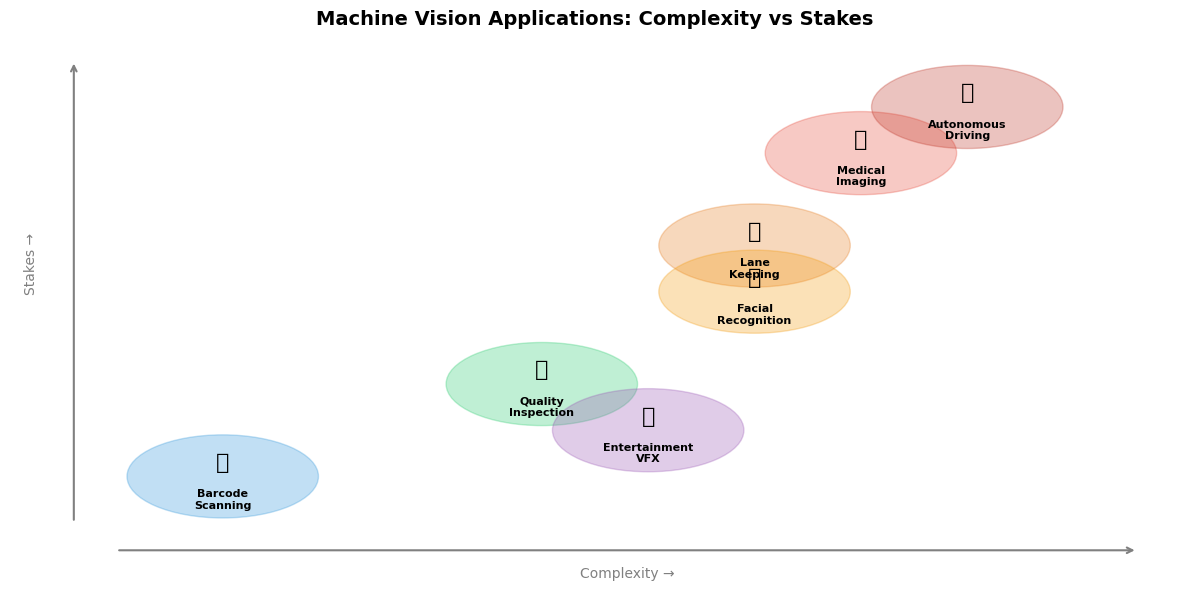

Applications range from simple (barcode scanning) to complex (autonomous driving)
Higher stakes = higher accuracy and reliability requirements

Saved: step9_applications.png


In [11]:
# ============================================================
# 步骤 9：应用领域概览
# Step 9: Application Domains Overview
# ============================================================
print("\n" + "=" * 60)
print("Step 9: Application Domains Overview")
print("=" * 60)

fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT // 2 + 2))
ax.axis('off')

# 应用矩阵：日常 vs 高级，低复杂度 vs 高复杂度
# Application matrix: everyday vs advanced, low vs high complexity
applications = [
    # (name, x_complexity, y_stakes, color, icon_text)
    ("Barcode\nScanning", 1, 1, '#3498DB', '🏪'),
    ("Quality\nInspection", 2.5, 2, '#2ECC71', '🏭'),
    ("Entertainment\nVFX", 3, 1.5, '#9B59B6', '🎮'),
    ("Lane\nKeeping", 3.5, 3.5, '#E67E22', '🚗'),
    ("Medical\nImaging", 4, 4.5, '#E74C3C', '🏥'),
    ("Autonomous\nDriving", 4.5, 5, '#C0392B', '🤖'),
    ("Facial\nRecognition", 3.5, 3, '#F39C12', '👤'),
]

for name, x, y, color, icon in applications:
    circle = plt.Circle((x, y), 0.45, color=color, alpha=0.3)
    ax.add_patch(circle)
    ax.text(x, y + 0.15, icon, ha='center', va='center', fontsize=16)
    ax.text(x, y - 0.25, name, ha='center', va='center', fontsize=8, fontweight='bold')

ax.set_xlim(0, 5.5)
ax.set_ylim(0, 5.8)
ax.set_title("Machine Vision Applications: Complexity vs Stakes",
             fontsize=14, fontweight='bold')

# 添加轴标签
# Add axis labels
ax.annotate('', xy=(5.3, 0.2), xytext=(0.5, 0.2),
            arrowprops=dict(arrowstyle='->', color='gray', linewidth=1.5))
ax.text(2.9, -0.1, "Complexity →", ha='center', fontsize=10, color='gray')

ax.annotate('', xy=(0.3, 5.5), xytext=(0.3, 0.5),
            arrowprops=dict(arrowstyle='->', color='gray', linewidth=1.5))
ax.text(0.1, 3.0, "Stakes →", ha='center', fontsize=10, color='gray', rotation=90)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "step9_applications.png"), dpi=DPI, bbox_inches='tight')
plt.show()

print("Applications range from simple (barcode scanning) to complex (autonomous driving)")
print("Higher stakes = higher accuracy and reliability requirements")
print("\nSaved: step9_applications.png")


Step 10: Course Roadmap


C:\Users\40270\AppData\Local\Temp\ipykernel_23248\1500206698.py:61: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\40270\AppData\Local\Temp\ipykernel_23248\1500206698.py:62: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(OUTPUT_DIR, "step10_course_roadmap.png"), dpi=DPI, bbox_inches='tight')


D:\BaiduSyncdisk\workspace\python_workspace_2025\rehui-advisor-platform\aisd\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


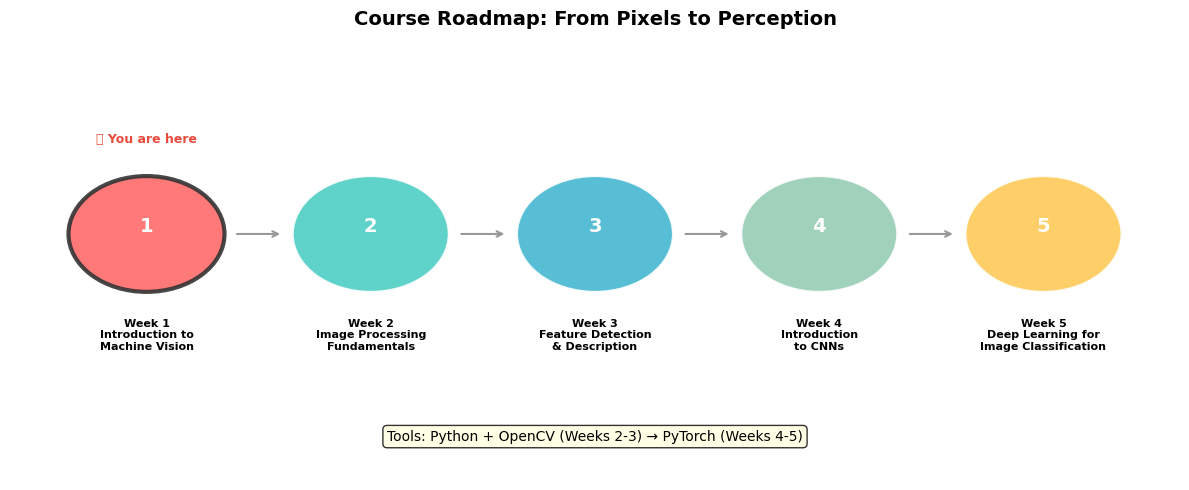

Week 1: Introduction to Machine Vision ← You are here
Week 2: Image Processing Fundamentals (OpenCV)
Week 3: Feature Detection & Description (OpenCV)
Week 4: Introduction to CNNs (PyTorch)
Week 5: Deep Learning for Image Classification (PyTorch)

Saved: step10_course_roadmap.png

All demos completed successfully!
Output directory: D:\BaiduSyncdisk\workspace\python_workspace_2025\aisd\courses\mv\notes\courses\mv\notes\week1_intro_complete_demo_pages


In [12]:
# ============================================================
# 步骤 10：课程路线图
# Step 10: Course Roadmap
# ============================================================
print("\n" + "=" * 60)
print("Step 10: Course Roadmap")
print("=" * 60)

fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT // 2 + 1))
ax.set_xlim(0, 6)
ax.set_ylim(-0.5, 2.5)
ax.axis('off')

weeks = [
    ("Week 1", "Introduction to\nMachine Vision", '#FF6B6B', True),
    ("Week 2", "Image Processing\nFundamentals", '#4ECDC4', False),
    ("Week 3", "Feature Detection\n& Description", '#45B7D1', False),
    ("Week 4", "Introduction\nto CNNs", '#96CEB4', False),
    ("Week 5", "Deep Learning for\nImage Classification", '#FECA57', False),
]

for i, (week, topic, color, is_current) in enumerate(weeks):
    x = i * 1.15 + 0.7
    y = 1.2

    # 圆形标记
    # Circle marker
    border_width = 3 if is_current else 1.5
    border_color = '#333' if is_current else 'white'
    circle = plt.Circle((x, y), 0.4, color=color, alpha=0.9,
                          ec=border_color, linewidth=border_width)
    ax.add_patch(circle)
    ax.text(x, y + 0.05, week.split()[1], ha='center', va='center',
            fontsize=14, fontweight='bold', color='white')

    # 标签
    # Label
    ax.text(x, y - 0.7, f"{week}\n{topic}", ha='center', va='center',
            fontsize=8, fontweight='bold')

    if is_current:
        ax.text(x, y + 0.65, "📍 You are here", ha='center', va='center',
                fontsize=9, fontweight='bold', color='#E74C3C')

    # 连接线
    # Connection line
    if i < len(weeks) - 1:
        next_x = (i + 1) * 1.15 + 0.7
        ax.annotate('', xy=(next_x - 0.45, y), xytext=(x + 0.45, y),
                     arrowprops=dict(arrowstyle='->', color='#999', linewidth=1.5))

# 工具栏
# Tool bar
tools_text = "Tools: Python + OpenCV (Weeks 2-3) → PyTorch (Weeks 4-5)"
ax.text(3, -0.2, tools_text, ha='center', va='center', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

ax.set_title("Course Roadmap: From Pixels to Perception",
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "step10_course_roadmap.png"), dpi=DPI, bbox_inches='tight')
plt.show()

print("Week 1: Introduction to Machine Vision ← You are here")
print("Week 2: Image Processing Fundamentals (OpenCV)")
print("Week 3: Feature Detection & Description (OpenCV)")
print("Week 4: Introduction to CNNs (PyTorch)")
print("Week 5: Deep Learning for Image Classification (PyTorch)")
print("\nSaved: step10_course_roadmap.png")

print("\n" + "=" * 60)
print("All demos completed successfully!")
print(f"Output directory: {OUTPUT_DIR}")
print("=" * 60)